# Setup

In [1]:
# ─────────────────────────────────────────────
# 04_crag_ablation.ipynb
#
# Purpose:
#   Build CRAG pipeline step by step and measure
#   contribution of each component independently.
#
#   Components measured:
#     v1: CRAG gate only (no fallback, no reranking)
#     v2: CRAG gate + BM25 fallback
#     v3: CRAG gate + BM25 fallback + reranking
#         (this is the final encoder-only system)
#
#   Also tunes CRAG threshold tau on val_tune set.
#
# Inputs:
#   data/cleaned_kb_docs.pkl
#   data/kb_index_cleaned.faiss
#   data/index_config.pkl
#   data/bm25_index.pkl
#   data/val_eval_mcq.pkl
#   data/val_tune_mcq.pkl
#   results/rag_baseline.json
#
# Outputs:
#   results/crag_tau_tuning.json
#   results/crag_v1.json
#   results/crag_v2.json
#   results/crag_v3.json          ← final encoder system
#   results/crag_ablation.json    ← full ablation table
#   models/crag_config.pkl
# ─────────────────────────────────────────────

!pip install faiss-cpu sentence-transformers rank-bm25 -q

import os
import sys
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict
from google.colab import drive

drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/MedQA_Project"
sys.path.insert(0, BASE)

from src.config import (
    DATA_DIR, RESULTS_DIR, MODELS_DIR, ensure_dirs,
    CLEANED_KB_PATH, FAISS_INDEX_PATH,
    INDEX_CONFIG_PATH, VAL_EVAL_MCQ_PATH,
    VAL_TUNE_MCQ_PATH, CE_BASE_MODEL, CRAG_TAU,
    CRAG_CONFIG_PATH,
)
from src.data_processing import load_pkl
from src.knowledge_base import load_faiss_index, load_bm25_index
from src.models import load_retriever, load_cross_encoder
from src.retriever import retrieve_faiss, retrieve_bm25
from src.crag import crag_gate, rerank_passages
from src.mcq_pipeline import (
    no_rag_pipeline, rag_pipeline,
    crag_pipeline, score_options,
)
from src.evaluation import (
    evaluate_pipeline, save_results,
    compute_faithfulness, compute_ece,
    analyse_failure_types, build_ablation_table,
    print_ablation_table,
)

ensure_dirs()

BM25_INDEX_PATH  = f"{DATA_DIR}/bm25_index.pkl"
TAU_TUNING_PATH  = f"{RESULTS_DIR}/crag_tau_tuning.json"
CRAG_V1_PATH     = f"{RESULTS_DIR}/crag_v1.json"
CRAG_V2_PATH     = f"{RESULTS_DIR}/crag_v2.json"
CRAG_V3_PATH     = f"{RESULTS_DIR}/crag_v3.json"
ABLATION_PATH    = f"{RESULTS_DIR}/crag_ablation.json"

print("Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 78.2 MB/s eta 0:00:00
Mounted at /content/drive
Setup complete



# Load all artifacts

In [2]:
# ─────────────────────────────────────────────
# Load all required artifacts
# ─────────────────────────────────────────────

cleaned_kb_docs = load_pkl(CLEANED_KB_PATH,  "cleaned_kb_docs")
val_eval_mcq    = load_pkl(VAL_EVAL_MCQ_PATH, "val_eval_mcq")
val_tune_mcq    = load_pkl(VAL_TUNE_MCQ_PATH, "val_tune_mcq")

kb_id_by_docid  = {doc['id']: (i, doc)
                    for i, doc in enumerate(cleaned_kb_docs)}

faiss_index, index_config = load_faiss_index()
bm25_index                = load_bm25_index(BM25_INDEX_PATH)
retriever                  = load_retriever()
cross_encoder              = load_cross_encoder(CE_BASE_MODEL)

# Load RAG baseline accuracy for comparison
with open(f"{RESULTS_DIR}/rag_baseline.json") as f:
    rag_data = json.load(f)
rag_acc = rag_data['accuracy']

print(f"\nAll artifacts loaded")
print(f"  KB docs:        {len(cleaned_kb_docs):,}")
print(f"  Val eval MCQ:   {len(val_eval_mcq):,}")
print(f"  Val tune MCQ:   {len(val_tune_mcq):,}")
print(f"  RAG baseline:   {rag_acc:.2f}%")

  Loaded cleaned_kb_docs
  Loaded val_eval_mcq
  Loaded val_tune_mcq
FAISS index loaded:
  Vectors: 156,555
  nprobe:  50
  Trained: True
  BM25 index loaded: 290,428 terms
Loading retriever: sentence-transformers/all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

  Max length: 512 tokens

All artifacts loaded
  KB docs:        156,555
  Val eval MCQ:   2,092
  Val tune MCQ:   2,091
  RAG baseline:   35.42%


# Tune CRAG threshold tau

In [3]:
# ─────────────────────────────────────────────
# Tune the CRAG gate threshold tau
#
# tau controls when the gate triggers BM25 fallback.
# Tuned on val_tune (not val_eval) to prevent
# information leakage into the evaluation set.
#
# Method:
#   For each tau value, simulate CRAG gate decision:
#     score >= tau → use FAISS passage
#     score <  tau → use empty context (no BM25 yet)
#   Pick tau that maximises val_tune accuracy
#   while keeping fallback rate reasonable
# ─────────────────────────────────────────────

if os.path.exists(TAU_TUNING_PATH):
    print("Tau tuning results already exist — loading\n")
    with open(TAU_TUNING_PATH) as f:
        tau_data = json.load(f)
    optimal_tau = tau_data['optimal_tau']
    print(f"Optimal tau: {optimal_tau}")

else:
    print("Tuning CRAG threshold tau on val_tune set...\n")
    print("Computing gate scores for all tune questions...")

    # Collect gate scores for all tune questions
    gate_records = []
    for qa in tqdm(val_tune_mcq[:500],
                   desc="Gate scores"):
        options  = [qa['opa'], qa['opb'],
                    qa['opc'], qa['opd']]
        passages = retrieve_faiss(
            qa['question'], faiss_index,
            cleaned_kb_docs, retriever, top_k=1)

        if not passages:
            continue

        gate_score = float(
            cross_encoder.predict(
                [(qa['question'],
                  passages[0]['text'])])[0])

        gate_records.append({
            "question":   qa['question'],
            "options":    options,
            "cop":        qa['cop'],
            "gate_score": gate_score,
            "passage":    passages[0]['text'],
            "subject":    qa['subject'],
        })

    print(f"Gate scores computed: {len(gate_records)}")

    # Compute baseline accuracy on this sample
    def score_with_passage(record, passage_text):
        opts  = record['options']
        pairs = [(f"{record['question']} {o}",
                  passage_text) for o in opts]
        scores = cross_encoder.predict(pairs)
        return int(np.argmax(scores))

    def score_no_context(record):
        return score_with_passage(
            record, "No additional context.")

    baseline_correct = sum(
        1 for g in gate_records
        if score_with_passage(
            g, g['passage']) == g['cop'])
    baseline_acc = baseline_correct / len(gate_records) * 100

    # Test different tau values
    tau_values = [-2.0, -1.0, 0.0, 0.5,
                   1.0, 2.0, 3.0, 4.0, 5.0]
    tau_results = {}

    print(f"\n{'tau':>8} {'Pass%':>7} {'Fail%':>7} "
          f"{'Acc%':>8} {'vs Base':>8}")
    print("-" * 45)

    for tau in tau_values:
        correct = 0
        n_pass  = 0
        n_fail  = 0

        for g in gate_records:
            if g['gate_score'] >= tau:
                pred  = score_with_passage(
                    g, g['passage'])
                n_pass += 1
            else:
                pred  = score_no_context(g)
                n_fail += 1

            if pred == g['cop']:
                correct += 1

        n   = len(gate_records)
        acc = correct / n * 100
        tau_results[str(tau)] = {
            "accuracy":     acc,
            "pass_rate":    n_pass / n,
            "fallback_rate":n_fail / n,
        }
        print(f"{tau:>8.1f} "
              f"{n_pass/n*100:>6.1f}% "
              f"{n_fail/n*100:>6.1f}% "
              f"{acc:>7.2f}% "
              f"{acc-baseline_acc:>+7.2f}%")

    # Select optimal tau
    optimal_tau = max(
        tau_results.keys(),
        key=lambda t: tau_results[t]['accuracy'])
    optimal_tau = float(optimal_tau)

    save_results({
        "optimal_tau":   optimal_tau,
        "baseline_acc":  baseline_acc,
        "results":       tau_results,
    }, TAU_TUNING_PATH, "crag_tau_tuning")

    print(f"\nOptimal tau: {optimal_tau}")
    print(f"Tune accuracy at optimal tau: "
          f"{tau_results[str(optimal_tau)]['accuracy']:.2f}%")

# Update CRAG config
crag_config = {"optimal_tau": optimal_tau}
with open(CRAG_CONFIG_PATH, "wb") as f:
    pickle.dump(crag_config, f)
print(f"\nCRAG config saved (tau={optimal_tau})")

Tau tuning results already exist — loading

Optimal tau: 0.5

CRAG config saved (tau=0.5)


#  CRAG v1: Gate only

In [4]:
# ─────────────────────────────────────────────
# CRAG v1 — Gate only
#
# Adds cross-encoder gate to RAG baseline.
# If gate fails → uses empty context (no BM25 yet)
# Measures: gate contribution in isolation
#
# Expected: small improvement over RAG baseline
# The gate alone helps little without fallback
# because we have nothing better to offer
# when gate rejects the FAISS passage
# ─────────────────────────────────────────────

if os.path.exists(CRAG_V1_PATH):
    print("CRAG v1 results already exist — loading\n")
    with open(CRAG_V1_PATH) as f:
        crag_v1_data = json.load(f)
    crag_v1_acc = crag_v1_data['accuracy']

else:
    print(f"Running CRAG v1 (gate only, tau={optimal_tau})...\n")

    def crag_v1_fn(question, options):
        """Gate only — no BM25 fallback."""
        passages = retrieve_faiss(
            question, faiss_index,
            cleaned_kb_docs, retriever, top_k=5)

        if not passages:
            top_text = "No context."
            rtype    = "no_faiss"
        else:
            gate = crag_gate(
                question, passages[0]['text'],
                cross_encoder, tau=optimal_tau)

            if gate['passed']:
                top_text = passages[0]['text']
                rtype    = "faiss"
            else:
                # Gate failed — no fallback yet
                top_text = "No context."
                rtype    = "gate_rejected"

        result = score_options(
            question, options, top_text, cross_encoder)
        return {**result,
                "retrieval_type": rtype,
                "source_passage": top_text[:200],
                "source_subject": passages[0]['subject']
                if passages and rtype == "faiss"
                else "Unknown",
                "gate_score": None}

    crag_v1_eval = evaluate_pipeline(
        val_eval_mcq, crag_v1_fn, desc="CRAG v1")

    crag_v1_acc  = crag_v1_eval['accuracy']
    crag_v1_data = {
        "system":          "crag_v1",
        "tau":             optimal_tau,
        "accuracy":        crag_v1_acc,
        "correct":         crag_v1_eval['correct'],
        "total":           crag_v1_eval['total'],
        "retrieval_counts":crag_v1_eval['retrieval_counts'],
        "subject_accuracy":crag_v1_eval['subject_accuracy'],
        "results":         crag_v1_eval['results'],
    }
    save_results(crag_v1_data, CRAG_V1_PATH, "crag_v1")

print(f"CRAG v1 accuracy: {crag_v1_acc:.2f}%")
print(f"RAG baseline:     {rag_acc:.2f}%")
print(f"Gate contribution: {crag_v1_acc-rag_acc:+.2f}%")

Running CRAG v1 (gate only, tau=0.5)...



CRAG v1: 100%|██████████| 2092/2092 [01:03<00:00, 33.03it/s]


  Saved crag_v1: 1184.2 KB
CRAG v1 accuracy: 35.04%
RAG baseline:     35.42%
Gate contribution: -0.38%


# CRAG v2: Gate + BM25 fallback

In [5]:
# ─────────────────────────────────────────────
# CRAG v2 — Gate + BM25 fallback
#
# When gate rejects FAISS passage, BM25 retrieval
# is triggered with query expansion using options.
# BM25 and FAISS gate scores are compared —
# whichever passage scores higher is used.
#
# Expected: largest single component gain
# BM25 directly addresses Type 1 failures
# ─────────────────────────────────────────────

if os.path.exists(CRAG_V2_PATH):
    print("CRAG v2 results already exist — loading\n")
    with open(CRAG_V2_PATH) as f:
        crag_v2_data = json.load(f)
    crag_v2_acc = crag_v2_data['accuracy']

else:
    print(f"Running CRAG v2 "
          f"(gate + BM25, tau={optimal_tau})...\n")

    def crag_v2_fn(question, options):
        """Gate + BM25 fallback, no reranking."""
        faiss_p = retrieve_faiss(
            question, faiss_index,
            cleaned_kb_docs, retriever, top_k=5)

        if not faiss_p:
            passages = retrieve_bm25(
                question, options,
                bm25_index, cleaned_kb_docs, top_k=5)
            rtype = "bm25_primary"
        else:
            gate = crag_gate(
                question, faiss_p[0]['text'],
                cross_encoder, tau=optimal_tau)

            if gate['passed']:
                passages = faiss_p
                rtype    = "faiss"
            else:
                bm25_p = retrieve_bm25(
                    question, options,
                    bm25_index, cleaned_kb_docs, top_k=5)

                if bm25_p:
                    bm25_gate = crag_gate(
                        question, bm25_p[0]['text'],
                        cross_encoder,
                        tau=optimal_tau - 1.0)
                    if bm25_gate['score'] > gate['score']:
                        passages = bm25_p
                        rtype    = "bm25_fallback"
                    else:
                        passages = faiss_p
                        rtype    = "faiss_forced"
                else:
                    passages = faiss_p
                    rtype    = "faiss_forced"

        top_text = passages[0]['text'] \
                    if passages else "No context."
        top_subj = passages[0]['subject'] \
                    if passages else "Unknown"

        result = score_options(
            question, options, top_text, cross_encoder)
        return {**result,
                "retrieval_type": rtype,
                "source_passage": top_text[:200],
                "source_subject": top_subj,
                "gate_score":     None}

    crag_v2_eval = evaluate_pipeline(
        val_eval_mcq, crag_v2_fn, desc="CRAG v2")

    crag_v2_acc  = crag_v2_eval['accuracy']
    crag_v2_data = {
        "system":          "crag_v2",
        "tau":             optimal_tau,
        "accuracy":        crag_v2_acc,
        "correct":         crag_v2_eval['correct'],
        "total":           crag_v2_eval['total'],
        "retrieval_counts":crag_v2_eval['retrieval_counts'],
        "subject_accuracy":crag_v2_eval['subject_accuracy'],
        "results":         crag_v2_eval['results'],
    }
    save_results(crag_v2_data, CRAG_V2_PATH, "crag_v2")

print(f"CRAG v2 accuracy:  {crag_v2_acc:.2f}%")
print(f"CRAG v1 accuracy:  {crag_v1_acc:.2f}%")
print(f"BM25 contribution: {crag_v2_acc-crag_v1_acc:+.2f}%")
print(f"\nRetrieval breakdown:")
for rtype, count in crag_v2_data[
        'retrieval_counts'].items():
    pct = count / len(val_eval_mcq) * 100
    print(f"  {rtype:<20} {count:>5,} ({pct:.1f}%)")

Running CRAG v2 (gate + BM25, tau=0.5)...



CRAG v2: 100%|██████████| 2092/2092 [28:14<00:00,  1.23it/s]

  Saved crag_v2: 1355.3 KB
CRAG v2 accuracy:  39.29%
CRAG v1 accuracy:  35.04%
BM25 contribution: +4.25%

Retrieval breakdown:
  faiss_forced           636 (30.4%)
  faiss                  958 (45.8%)
  bm25_fallback          498 (23.8%)


# CRAG v3: Gate + BM25 + Reranking

In [6]:
# ─────────────────────────────────────────────
# CRAG v3 — Gate + BM25 fallback + Reranking
#
# After retrieval (FAISS or BM25), all passages
# are reranked by cross-encoder relevance score.
# The top-ranked passage (not top FAISS passage)
# is used for option scoring.
#
# This is the FINAL ENCODER-ONLY SYSTEM.
# ─────────────────────────────────────────────

if os.path.exists(CRAG_V3_PATH):
    print("CRAG v3 results already exist — loading\n")
    with open(CRAG_V3_PATH) as f:
        crag_v3_data = json.load(f)
    crag_v3_acc = crag_v3_data['accuracy']

else:
    print(f"Running CRAG v3 "
          f"(gate + BM25 + reranking, "
          f"tau={optimal_tau})...\n")

    crag_v3_eval = evaluate_pipeline(
        val_eval_mcq,
        lambda q, opts: crag_pipeline(
            q, opts, faiss_index, bm25_index,
            cleaned_kb_docs, retriever,
            cross_encoder, tau=optimal_tau),
        desc="CRAG v3 (final encoder system)",
    )

    crag_v3_acc  = crag_v3_eval['accuracy']

    # Full metrics for final system
    faithfulness  = compute_faithfulness(
        crag_v3_eval['results'])
    ece           = compute_ece(
        crag_v3_eval['results'])
    failure_types = analyse_failure_types(
        crag_v3_eval['results'], kb_id_by_docid)

    crag_v3_data = {
        "system":          "crag_v3",
        "description":     "Final encoder-only system",
        "tau":             optimal_tau,
        "accuracy":        crag_v3_acc,
        "correct":         crag_v3_eval['correct'],
        "total":           crag_v3_eval['total'],
        "faithfulness":    faithfulness,
        "ece":             ece['ece'],
        "ece_bins":        ece['bin_data'],
        "failure_types":   failure_types,
        "retrieval_counts":crag_v3_eval['retrieval_counts'],
        "subject_accuracy":crag_v3_eval['subject_accuracy'],
        "results":         crag_v3_eval['results'],
    }
    save_results(crag_v3_data, CRAG_V3_PATH, "crag_v3")

print(f"CRAG v3 accuracy:      {crag_v3_acc:.2f}%")
print(f"CRAG v2 accuracy:      {crag_v2_acc:.2f}%")
print(f"Reranking contribution:{crag_v3_acc-crag_v2_acc:+.2f}%")
print(f"\nRetrieval breakdown:")
for rtype, count in crag_v3_data[
        'retrieval_counts'].items():
    pct = count / len(val_eval_mcq) * 100
    print(f"  {rtype:<20} {count:>5,} ({pct:.1f}%)")

Running CRAG v3 (gate + BM25 + reranking, tau=0.5)...



CRAG v3 (final encoder system): 100%|██████████| 2092/2092 [29:02<00:00,  1.20it/s]

  Saved crag_v3: 1416.8 KB
CRAG v3 accuracy:      40.01%
CRAG v2 accuracy:      39.29%
Reranking contribution:+0.72%

Retrieval breakdown:
  faiss_forced           636 (30.4%)
  faiss                  958 (45.8%)
  bm25_fallback          498 (23.8%)


#  Full ablation table

In [7]:
# ─────────────────────────────────────────────
# Build and display the complete ablation table
# Shows contribution of each component
# ─────────────────────────────────────────────

ablation_systems = {
    "Random chance":         {"accuracy": 25.00},
    "No-RAG (CE only)":      {"accuracy": rag_data.get(
        'no_rag_accuracy', 28.97)},
    "RAG baseline":          {"accuracy": rag_acc},
    "CRAG v1 (gate)":        {"accuracy": crag_v1_acc},
    "CRAG v2 (+ BM25)":      {"accuracy": crag_v2_acc},
    "CRAG v3 (+ reranking)": {"accuracy": crag_v3_acc},
}

# Load no-rag accuracy from baseline comparison
try:
    with open(f"{RESULTS_DIR}/baseline_comparison.json") as f:
        cmp = json.load(f)
    no_rag_acc = cmp['no_rag']['accuracy']
    ablation_systems["No-RAG (CE only)"] = {
        "accuracy": no_rag_acc}
except Exception:
    pass

rows = build_ablation_table(ablation_systems)
print_ablation_table(rows)

# Component contributions
print("\nComponent contributions:")
contributions = [
    ("Model prior (CE)",  no_rag_acc  - 25.00),
    ("Dense retrieval",   rag_acc     - no_rag_acc),
    ("CRAG gate",         crag_v1_acc - rag_acc),
    ("BM25 fallback",     crag_v2_acc - crag_v1_acc),
    ("Reranking",         crag_v3_acc - crag_v2_acc),
]
for label, delta in contributions:
    bar = "█" * int(abs(delta) * 3)
    print(f"  {label:<20} {delta:>+6.2f}%  {bar}")

# Save ablation
ablation_data = {
    "systems":        ablation_systems,
    "rows":           rows,
    "contributions":  {l: round(d, 2)
                       for l, d in contributions},
}
save_results(ablation_data, ABLATION_PATH,
             "crag_ablation")


System                                         Accuracy    Delta
-----------------------------------------------------------------
Random chance                                    25.00%     ---  
No-RAG (CE only)                                 28.97%    +3.97%
RAG baseline                                     35.42%    +6.45%
CRAG v1 (gate)                                   35.04%    -0.38%
CRAG v2 (+ BM25)                                 39.29%    +4.25%
CRAG v3 (+ reranking)                            40.01%    +0.72%

Component contributions:
  Model prior (CE)      +3.97%  ███████████
  Dense retrieval       +6.45%  ███████████████████
  CRAG gate             -0.38%  █
  BM25 fallback         +4.25%  ████████████
  Reranking             +0.72%  ██
  Saved crag_ablation: 1.3 KB


#  Per-subject comparison


Subject                                 RAG  CRAG v3   Delta
--------------------------------------------------------------
Anaesthesia                           13.3%    20.0%   +6.7% ✅
Anatomy                               39.3%    46.4%   +7.1% ✅
Biochemistry                          39.4%    43.6%   +4.3%
Dental                                31.8%    34.7%   +2.9%
ENT                                   37.5%    29.2%   -8.3% ❌
Forensic Medicine                     48.1%    59.3%  +11.1% ✅
Gynaecology & Obstetrics              38.5%    51.4%  +12.8% ✅
Medicine                              33.5%    41.0%   +7.5% ✅
Microbiology                          31.7%    44.4%  +12.7% ✅
Ophthalmology                         57.7%    65.4%   +7.7% ✅
Orthopaedics                          45.5%    45.5%   +0.0%
Pathology                             35.7%    39.8%   +4.1%
Pediatrics                            37.7%    37.7%   +0.0%
Pharmacology                          39.8%    46.3%   +6.5% ✅
Phy

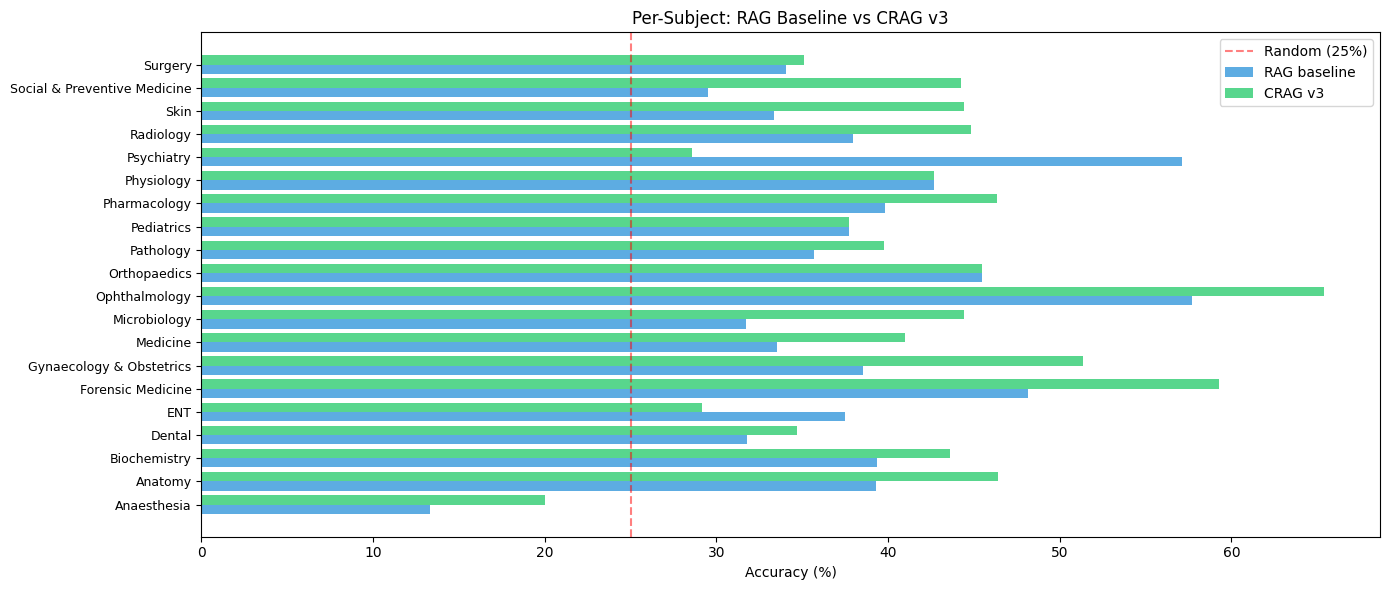

In [8]:
# ─────────────────────────────────────────────
# Compare per-subject accuracy:
# RAG baseline vs CRAG v3
# ─────────────────────────────────────────────

rag_subj  = rag_data['subject_accuracy']
crag_subj = crag_v3_data['subject_accuracy']

all_subjects = sorted(
    set(rag_subj.keys()) | set(crag_subj.keys()))

print(f"\n{'Subject':<35} {'RAG':>7} "
      f"{'CRAG v3':>8} {'Delta':>7}")
print("-" * 62)

improvements = []
for subj in all_subjects:
    if subj == "Unknown":
        continue
    rag_a  = rag_subj.get(subj, 0)
    crag_a = crag_subj.get(subj, 0)
    delta  = crag_a - rag_a
    flag   = " ✅" if delta > 5 else \
             " ❌" if delta < -5 else ""
    improvements.append((subj, rag_a, crag_a, delta))
    print(f"{subj:<35} {rag_a:>6.1f}% "
          f"{crag_a:>7.1f}% "
          f"{delta:>+6.1f}%{flag}")

print(f"\n{'Overall':<35} {rag_acc:>6.1f}% "
      f"{crag_v3_acc:>7.1f}% "
      f"{crag_v3_acc-rag_acc:>+6.1f}%")

# Chart
subjs   = [r[0] for r in improvements]
rag_acc_list  = [r[1] for r in improvements]
crag_acc_list = [r[2] for r in improvements]
x = np.arange(len(subjs))

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(x - 0.2, rag_acc_list,  0.4,
        label="RAG baseline", color="#3498DB", alpha=0.8)
ax.barh(x + 0.2, crag_acc_list, 0.4,
        label="CRAG v3", color="#2ECC71", alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(subjs, fontsize=9)
ax.axvline(25, color='red', ls='--',
           alpha=0.5, label='Random (25%)')
ax.set_xlabel("Accuracy (%)")
ax.set_title("Per-Subject: RAG Baseline vs CRAG v3")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/crag_subject_comparison.png",
            dpi=150)
plt.show()

# Ablation chart

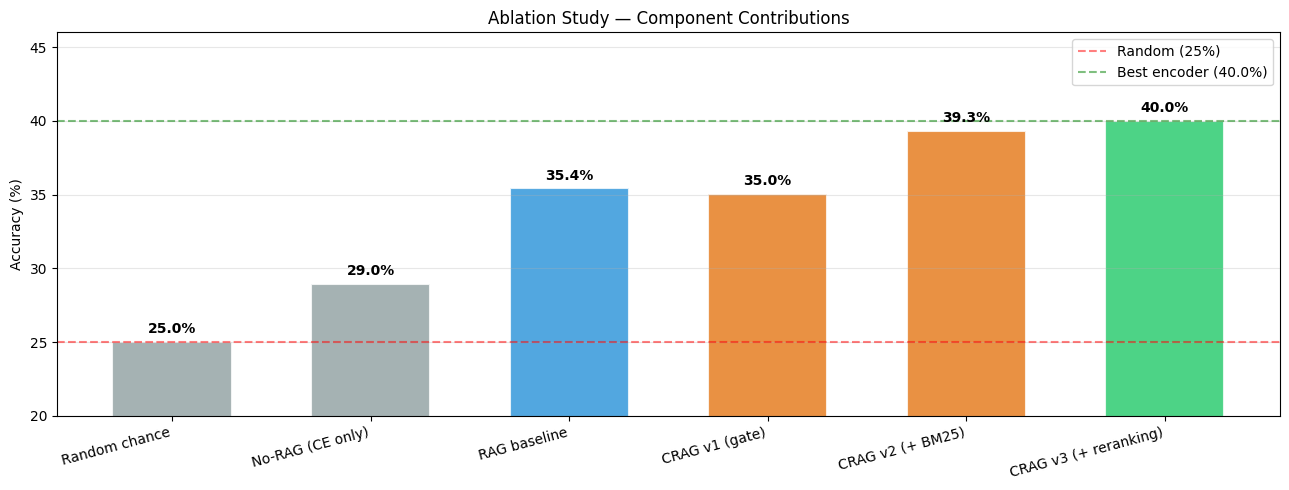

Ablation chart saved


In [9]:
# ─────────────────────────────────────────────
# Progressive ablation bar chart
# This is the key result figure for the report
# ─────────────────────────────────────────────

systems = list(ablation_systems.keys())
accs    = [ablation_systems[s]['accuracy']
            for s in systems]

colors = [
    "#95A5A6",  # random — grey
    "#95A5A6",  # no-rag — grey
    "#3498DB",  # rag — blue
    "#E67E22",  # crag v1 — orange
    "#E67E22",  # crag v2 — orange
    "#2ECC71",  # crag v3 — green (best encoder)
]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(range(len(systems)), accs,
               color=colors, alpha=0.85,
               edgecolor="white", linewidth=1.5,
               width=0.6)

# Value labels
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f"{acc:.1f}%",
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.axhline(25, color='red', ls='--',
            alpha=0.5, label='Random (25%)')
ax.axhline(crag_v3_acc, color='green', ls='--',
            alpha=0.5,
            label=f'Best encoder ({crag_v3_acc:.1f}%)')

ax.set_xticks(range(len(systems)))
ax.set_xticklabels(systems, rotation=15,
                    ha='right', fontsize=10)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(20, max(accs) + 6)
ax.set_title("Ablation Study — Component Contributions")
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/ablation_chart.png", dpi=150)
plt.show()
print("Ablation chart saved")

#  Final verification

In [10]:
# ─────────────────────────────────────────────
# Verify all Notebook 04 outputs
# ─────────────────────────────────────────────

print("NOTEBOOK 04 — FINAL VERIFICATION\n")

checks = [
    (TAU_TUNING_PATH,  "crag_tau_tuning.json",      True),
    (CRAG_V1_PATH,     "crag_v1.json",               True),
    (CRAG_V2_PATH,     "crag_v2.json",               True),
    (CRAG_V3_PATH,     "crag_v3.json",               True),
    (ABLATION_PATH,    "crag_ablation.json",          True),
    (CRAG_CONFIG_PATH, "crag_config.pkl",             True),
    (f"{RESULTS_DIR}/ablation_chart.png",
     "ablation_chart.png", True),
    (f"{RESULTS_DIR}/crag_subject_comparison.png",
     "crag_subject_comparison.png", True),
]

all_ok = True
for path, label, required in checks:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    status = "✅" if exists else "❌"
    if not exists and required:
        all_ok = False
    print(f"  {status} {label:<40} {size:>8.1f} KB")

print(f"\nAblation summary:")
print(f"  Random:        25.00%")
print(f"  No-RAG:        {no_rag_acc:.2f}%")
print(f"  RAG baseline:  {rag_acc:.2f}%")
print(f"  CRAG v1:       {crag_v1_acc:.2f}%")
print(f"  CRAG v2:       {crag_v2_acc:.2f}%")
print(f"  CRAG v3:       {crag_v3_acc:.2f}%  ← final encoder")
print(f"  Optimal tau:   {optimal_tau}")
print()
if all_ok:
    print("All checks passed ✅")
else:
    print("Some checks failed ❌ — review above")

NOTEBOOK 04 — FINAL VERIFICATION

  ✅ crag_tau_tuning.json                          1.0 KB
  ✅ crag_v1.json                               1184.2 KB
  ✅ crag_v2.json                               1355.3 KB
  ✅ crag_v3.json                               1416.8 KB
  ✅ crag_ablation.json                            1.3 KB
  ✅ crag_config.pkl                               0.0 KB
  ✅ ablation_chart.png                           90.8 KB
  ✅ crag_subject_comparison.png                  91.6 KB

Ablation summary:
  Random:        25.00%
  No-RAG:        28.97%
  RAG baseline:  35.42%
  CRAG v1:       35.04%
  CRAG v2:       39.29%
  CRAG v3:       40.01%  ← final encoder
  Optimal tau:   0.5

All checks passed ✅
